In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
%reload_ext autoreload
%autoreload 2

[Lecture Notes](https://www.youtube.com/watch?v=IP7R-gnDF9w)

In [3]:
import pandas as pd
import networkx as nx

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from src.cointegration.sparse import SparseMeanReversionPortfolio

In [4]:
# Load data.
etf_df = pd.read_csv("../data/sample-data/Country_ETF.csv", parse_dates=["Dates"])
etf_df.set_index("Dates", inplace=True)
etf_df.fillna(method='ffill', inplace=True)
etf_df.columns = [x.split()[0] for x in etf_df.columns]

# Construct the sparse mean-reverting portfolio selection class.
etf_sparse_portf = SparseMeanReversionPortfolio(etf_df)

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_81112/3055162687.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  etf_df.fillna(method='ffill', inplace=True)


In [5]:
etf_sparse_portf.assets.head(5)

,KSA,EWM,EGPT,EFNL,EWG,ENZL,EWL,EZA,NGE,EDEN,...,EWT,EWZ,VNM,EWW,NORW,GXG,ECH,EWO,EWY,TUR
Dates,,,,,,,,,,,,,,,,,,,,,
2016-01-01,24.2199,30.96,38.2100,32.61,26.19,37.48,31.04,46.71,28.24,55.8501,...,25.54,20.68,14.79,49.83,9.69,29.84,31.92,15.65,49.67,36.36
2016-01-04,23.5300,29.96,37.1290,32.43,25.56,37.20,30.69,45.61,27.88,55.6000,...,24.76,19.94,14.97,49.07,9.77,29.32,31.57,15.47,48.51,35.32
2016-01-05,23.5300,30.20,37.5000,31.90,25.32,36.72,30.62,45.77,27.76,55.2142,...,24.68,20.22,15.00,48.92,9.41,29.56,31.80,15.46,48.72,35.16
2016-01-06,22.6600,29.52,37.1000,31.46,25.03,36.21,30.16,44.38,27.32,55.0200,...,24.12,19.92,14.67,47.92,9.15,28.64,31.55,15.26,47.75,34.96
2016-01-07,21.8900,29.40,35.7811,31.32,24.53,35.80,29.67,42.14,26.52,54.3400,...,23.56,19.18,14.34,46.05,8.90,28.04,30.45,15.04,46.99,34.99


## Sparse Portfolio Selection (Optimal)

> No cardinality constraint on the number of assets in our portfolio

In [6]:
# Calculate the penalized estimates.
sparse_var_est = etf_sparse_portf.LASSO_VAR_fit(1.4, threshold = 7, multi_task_lasso = True)
_, sparse_prec_est = etf_sparse_portf.covar_sparse_fit(0.89)

# Generate the clusters.
multi_LASSO_cluster_graph = etf_sparse_portf.find_clusters(sparse_prec_est, sparse_var_est)
multi_LASSO_clusters = list(sorted(nx.connected_components(multi_LASSO_cluster_graph), key = len, reverse = True))

# Check the first two clusters.
print("1st cluster: {}\nAsset count: {}".format(multi_LASSO_clusters[0], len(multi_LASSO_clusters[0])))
print("2nd cluster: {}\nAsset count: {}".format(multi_LASSO_clusters[1], len(multi_LASSO_clusters[1])))

1st cluster: {'EFNL', 'EWG', 'EWI', 'INDA', 'GXC', 'EWJ', 'EWL', 'EDEN', 'EWY', 'EWQ', 'EWN', 'EWT', 'ENZL', 'EWK', 'EIRL'}
Asset count: 15
2nd cluster: {'THD', 'EWS', 'ECH', 'EWO', 'EZA', 'EWU', 'GXG', 'EWP'}
Asset count: 8


<div class="alert alert-block alert-info">
<b>Tip:</b> Covariance selection determines the size of the clusters. When fitting the graphical LASSO model, apply a larger regularizer parameter to make the covariance matrix as sparse as possible such that smaller clusters are obtained. </div> 

<div class="alert alert-block alert-info">
<b>Tip:</b> Both graphical LASSO model and LASSO regression are sensitive to the scale of the data. Use standardized data for this step, otherwise the LASSO models will not be able to yield a reasonable, or even feasible, solution.</div> 

The second cluster looks quite sparse. Now perform a Box-Tiao canonical decomposition on this small cluster.

In [7]:
# Construct another class on the cluster obtained previously.
small_etf_sparse_portf = SparseMeanReversionPortfolio(etf_df[list(multi_LASSO_clusters[1])])

# Check the data.
small_etf_sparse_portf.assets.head(5)

,THD,EWS,ECH,EWO,EZA,EWU,GXG,EWP
Dates,,,,,,,,
2016-01-01,58.64,20.56,31.92,15.65,46.71,32.28,29.84,28.27
2016-01-04,57.71,20.10,31.57,15.47,45.61,31.76,29.32,27.89
2016-01-05,57.58,20.18,31.80,15.46,45.77,31.68,29.56,27.65
2016-01-06,56.97,19.78,31.55,15.26,44.38,31.10,28.64,27.13
2016-01-07,55.01,19.24,30.45,15.04,42.14,30.24,28.04,26.74


In [8]:
# Perform Box-Tiao canonical decomposition.
bt_weights = small_etf_sparse_portf.box_tiao()

# Retrieve the portfolio weights that corresponds to the smallest eigenvalue.
sparse_portf_weight1 = bt_weights[:, -1]

# Check weights and pretty print the results.
sparse_portf_weight_df = pd.DataFrame(sparse_portf_weight1.reshape(-1, 1))
sparse_portf_weight_df.columns = ['Weight']
sparse_portf_weight_df.index = small_etf_sparse_portf.assets.columns

sparse_portf_weight_df

/Users/oriolripalta/Desktop/Projects/QuantTrading/venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


,Weight
THD,-0.109448
EWS,0.666222
ECH,0.104442
EWO,0.145805
EZA,-0.105541
EWU,-0.640490
GXG,0.259847
EWP,-0.152039


In [9]:
# Form the portfolio.
sparse_portf1 = small_etf_sparse_portf.assets @ sparse_portf_weight1

# Fit an OU-model to see the mean-reversion speed parameter and half-life.
coeff, hl = small_etf_sparse_portf.mean_rev_coeff(sparse_portf_weight1, small_etf_sparse_portf.assets)
print("Mean-rev Coefficient: {}; half-life: {}".format(coeff, hl))

Mean-rev Coefficient: 19.804537204594162; half-life: 8.819852122602814


In [10]:
def plot_portf(portf_data, title):
    years = mdates.YearLocator()  # every year
    months = mdates.MonthLocator()  # every month
    years_fmt = mdates.DateFormatter('%Y')

    fig, ax = plt.subplots(1,1, figsize=(15, 5), sharex=True)

    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.xaxis.set_minor_locator(months)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)

    ax.set_title(title, fontsize=18)
    ax.plot(portf_data, label='Weak Mean-reversion')
    ax.axhline(portf_data.mean(), linewidth=0.3, linestyle='--', color=(0, 0, 0, 0.85))
    ax.set_xlim(pd.Timestamp(2016, 1, 1), pd.Timestamp(2021, 2,1))

    plt.show()

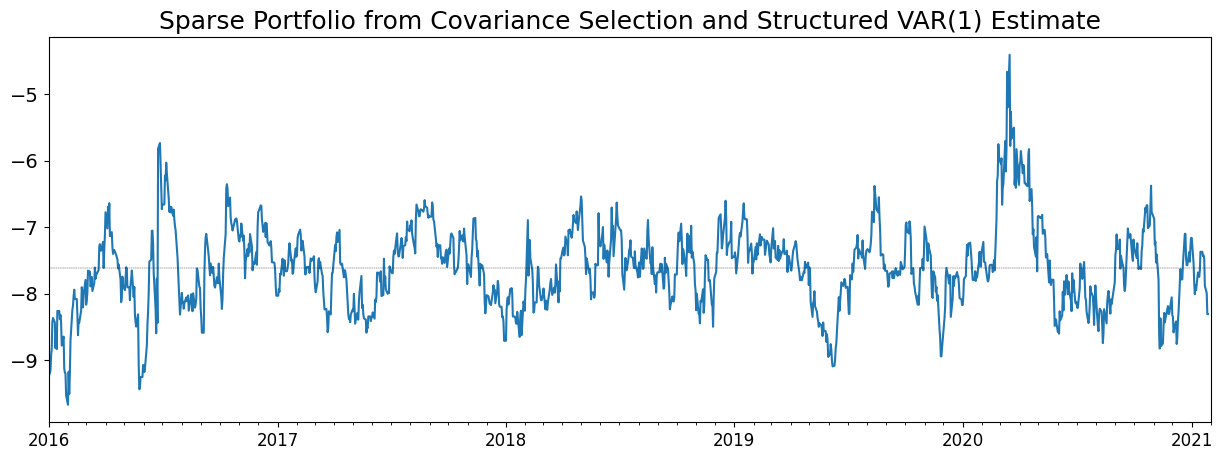

In [11]:
plot_portf(sparse_portf1, "Sparse Portfolio from Covariance Selection and Structured VAR(1) Estimate")

## Sparse Portfolio Selection (Greedy)

> Added cardinality constraint on the number of assets in our portfolio

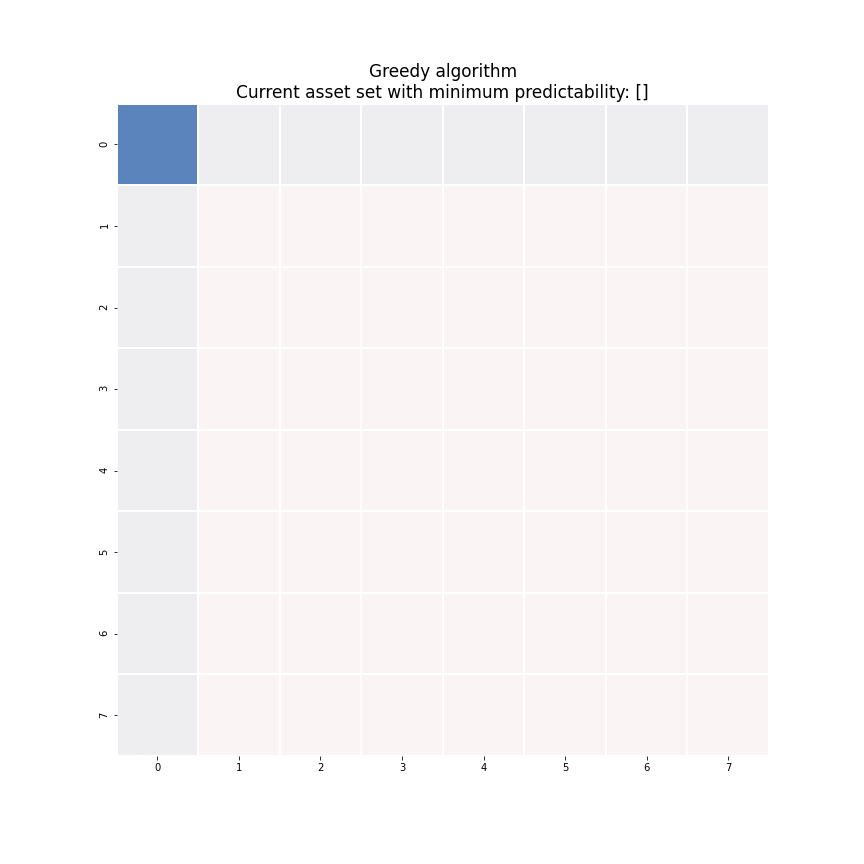

In [12]:
from IPython.display import Image
Image(filename='../images/greedy_demo.gif')

**Note**: The example in this section uses data of all 45 ETFs and attempts to construct a sparse mean-reverting portfolio with greedy algorithm. The sample covariance matrix and the least-square VAR(1) estimate were used here to demonstrate that the greedy algorithm can work well even without the preprocessing step with covariance selection and penalized regression.

In [13]:
# Calculate least-square VAR(1) estimate and sample covariance.
full_var_est = etf_sparse_portf.least_square_VAR_fit()
full_cov_est = etf_sparse_portf.autocov(0, use_standardized=False)

# Use greedy algorithm to calculate portfolio weights.
greedy_weight = etf_sparse_portf.greedy_search(8, full_var_est, full_cov_est, maximize=False)

# Pretty print the weights.
greedy_weight_df = pd.DataFrame(greedy_weight.reshape(-1, 1))
greedy_weight_df.columns = ['Weight']
greedy_weight_df.index = etf_sparse_portf.assets.columns

# Print only the non-zero weights.
greedy_weight_df[greedy_weight_df['Weight'] != 0]

/Users/oriolripalta/Desktop/Projects/QuantTrading/venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


,Weight
EGPT,-0.035084
ARGT,-0.332868
EWZ,0.206248
EWW,0.504653
GXG,-0.680563
ECH,0.315425
EWY,-0.026486
TUR,-0.165515


In [14]:
# Build the portfolio and check the OU model fit.
greedy_portf = etf_sparse_portf.assets @ greedy_weight

coeff, hl = etf_sparse_portf.mean_rev_coeff(greedy_weight.squeeze(), etf_sparse_portf.assets)
print("Mean-rev Coefficient: {}; half-life: {}".format(coeff, hl))

Mean-rev Coefficient: 6.330519385257875; half-life: 27.5922209333841


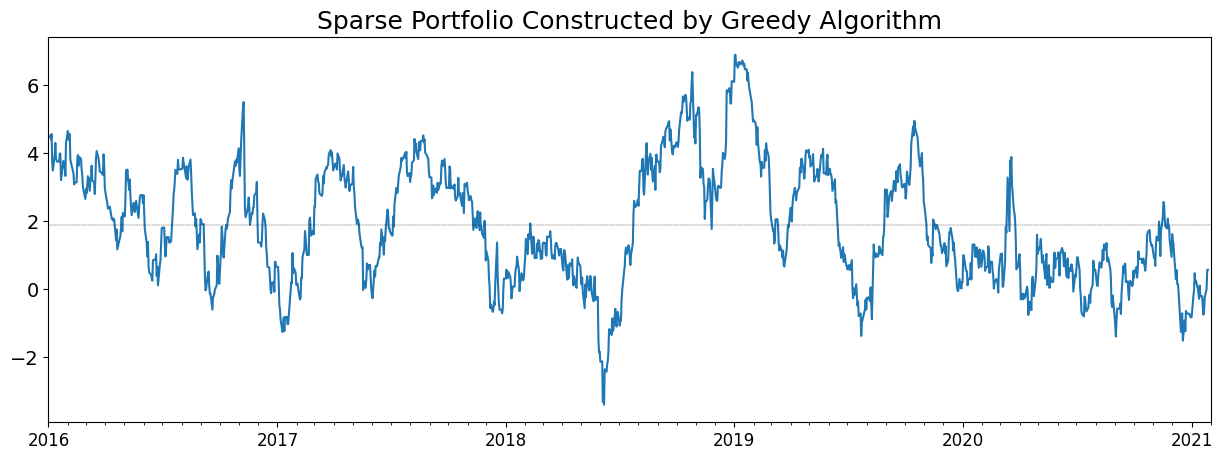

In [15]:
plot_portf(greedy_portf.squeeze(), "Sparse Portfolio Constructed by Greedy Algorithm")

## Sparse Portfolio Selection (Convex Relaxation)

### Predictability

In [17]:
# Solve the predictability SDP.
sdp_pred_vol_result = etf_sparse_portf.sdp_predictability_vol(rho=0.001, variance=5, 
                                                              max_iter=5000, use_standardized=False,
                                                              verbose=False)

# Deflate the optimization result into a weight vector.
sdp_pred_vol_weights = etf_sparse_portf.sparse_eigen_deflate(sdp_pred_vol_result, 8, verbose=False)

In [18]:
# Build the portfolio and check the OU model fit.
sdp_pred_vol_portf = etf_sparse_portf.assets @ sdp_pred_vol_weights

coeff, hl = etf_sparse_portf.mean_rev_coeff(sdp_pred_vol_weights.squeeze(), etf_sparse_portf.assets)
print("Mean-rev Coefficient: {}; half-life: {}".format(coeff, hl))

Mean-rev Coefficient: 10.211477667728792; half-life: 17.10556446234255


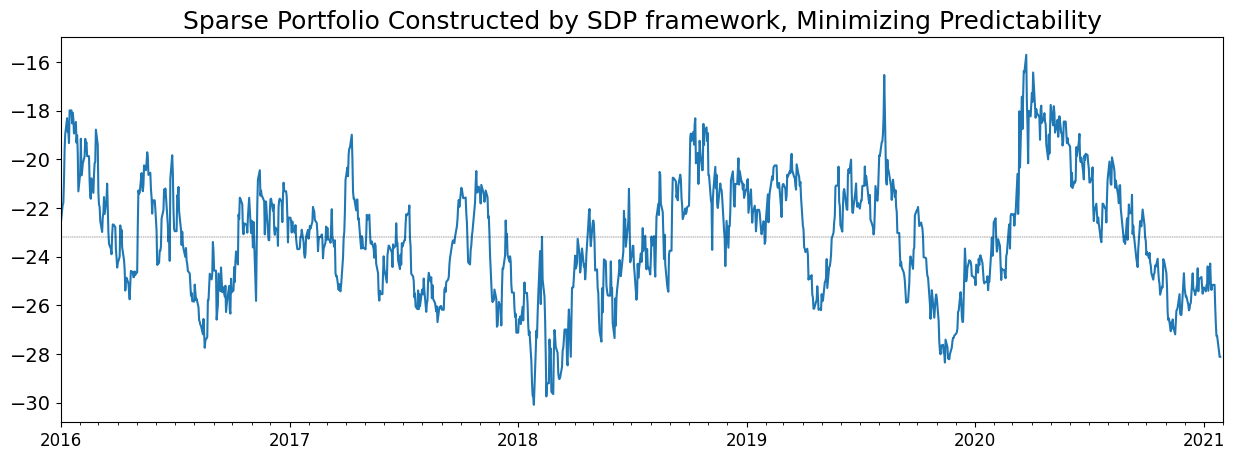

In [19]:
plot_portf(sdp_pred_vol_portf.squeeze(), "Sparse Portfolio Constructed by SDP framework, Minimizing Predictability")

### Portmanteau

In [20]:
# Solve the portmanteau SDP.
sdp_portmanteau_vol_result = etf_sparse_portf.sdp_portmanteau_vol(rho=0.001, variance=5, nlags=3,
                                                                  max_iter=10000, use_standardized=False,
                                                                  verbose=False)

# Deflate the optimization result into a weight vector.
sdp_portmanteau_vol_weights = etf_sparse_portf.sparse_eigen_deflate(sdp_portmanteau_vol_result, 8, verbose=False)

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/cointegration/sparse.py:350: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(cp.Minimize(problem), constraints).solve(verbose=verbose, solver='SCS', max_iters=max_iter)


In [21]:
# Pretty print the weights.
sdp_portmanteau_vol_weight_df = pd.DataFrame(sdp_portmanteau_vol_weights.reshape(-1, 1))
sdp_portmanteau_vol_weight_df.columns = ['Weight']
sdp_portmanteau_vol_weight_df.index = etf_sparse_portf.assets.columns

# Print only the non-zero weights.
sdp_portmanteau_vol_weight_df[sdp_portmanteau_vol_weight_df['Weight'] != 0]

,Weight
EZA,0.381182
EDEN,-0.405786
GXC,0.469002
EPU,-0.309560
EIRL,-0.241742
ARGT,-0.314045
EIS,0.300105
EWW,0.356540


In [22]:
# Build the portfolio and check the OU model fit.
sdp_portmanteau_vol_portf = etf_sparse_portf.assets @ sdp_portmanteau_vol_weights

coeff, hl = etf_sparse_portf.mean_rev_coeff(sdp_portmanteau_vol_weights.squeeze(), etf_sparse_portf.assets)
print("Mean-rev Coefficient: {}; half-life: {}".format(coeff, hl))

Mean-rev Coefficient: 4.629826462254419; half-life: 37.72778330357807


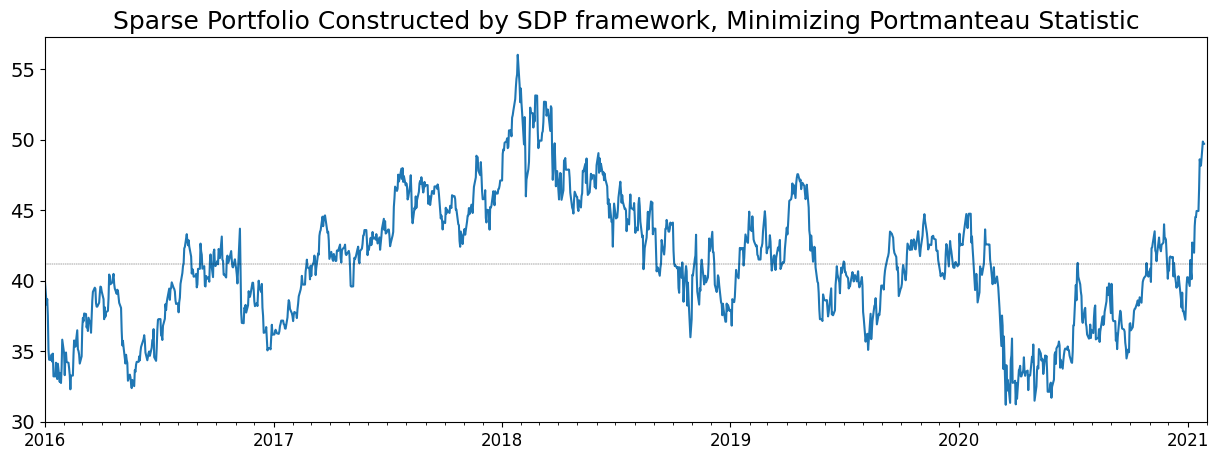

In [24]:
plot_portf(sdp_portmanteau_vol_portf.squeeze(), "Sparse Portfolio Constructed by SDP framework, Minimizing Portmanteau Statistic")

### Crossing Statistic

In [25]:
# Solve the crossing statistic SDP.
sdp_crossing_vol_result = etf_sparse_portf.sdp_crossing_vol(rho=0.002, mu=0.1, variance=5, nlags=4,
                                                            max_iter=10000, use_standardized=False,
                                                            verbose=False)

# Deflate the optimization result into a weight vector.
sdp_crossing_vol_weights = etf_sparse_portf.sparse_eigen_deflate(sdp_crossing_vol_result, 8, verbose=False)

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/cointegration/sparse.py:403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(cp.Minimize(problem), constraints).solve(verbose=verbose, solver='SCS', max_iters=max_iter)
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/cointegration/sparse.py:509: UserWarning: The SDP result is not positive semidefinite due to numerical issues. Please double check if the negative eigenvalues are sufficiently small that they can be approximated as 0.
  warnings.warn("The SDP result is not positive semidefinite due to numerical issues. Please double check"


In [26]:
# Pretty print the weights.
sdp_crossing_vol_weight_df = pd.DataFrame(sdp_crossing_vol_weights.reshape(-1, 1))
sdp_crossing_vol_weight_df.columns = ['Weight']
sdp_crossing_vol_weight_df.index = etf_sparse_portf.assets.columns

# Print only the non-zero weights.
sdp_crossing_vol_weight_df[sdp_crossing_vol_weight_df['Weight'] != 0]

,Weight
EZA,0.334725
EDEN,-0.431370
GXC,0.505852
EPU,-0.295901
EIRL,-0.252218
ARGT,-0.294853
EIS,0.279391
EWW,0.360311


In [27]:
# Build the portfolio and check the OU model fit.
sdp_crossing_vol_portf = etf_sparse_portf.assets @ sdp_crossing_vol_weights

coeff, hl = etf_sparse_portf.mean_rev_coeff(sdp_crossing_vol_weights.squeeze(), etf_sparse_portf.assets)
print("Mean-rev Coefficient: {}; half-life: {}".format(coeff, hl))

Mean-rev Coefficient: 4.501921943021799; half-life: 38.79967083211163


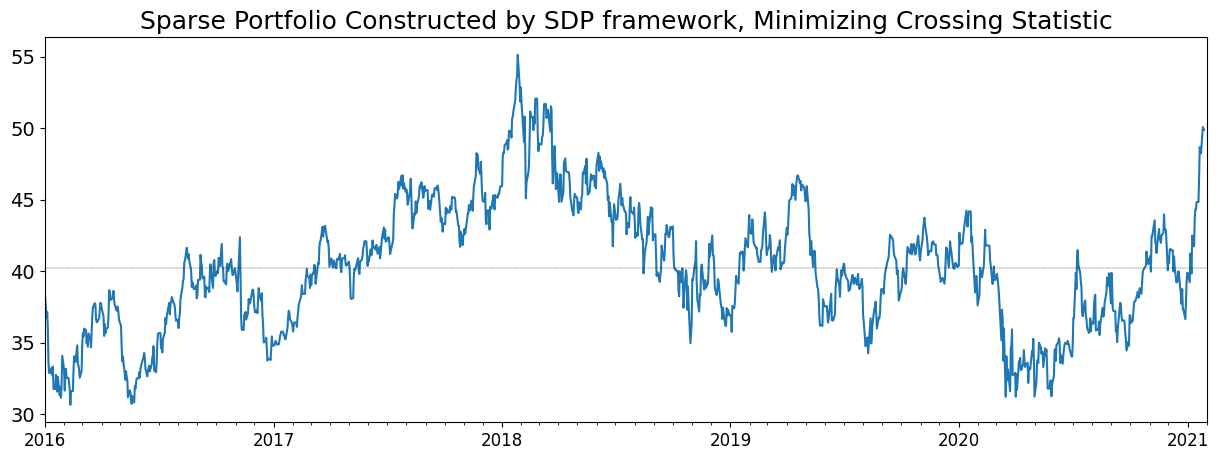

In [30]:
plot_portf(sdp_crossing_vol_portf.squeeze(), "Sparse Portfolio Constructed by SDP framework, Minimizing Crossing Statistic")

## Conclusion

Among the three approaches, greedy algorithm is the most robust due to its simplicity and the stableness of the portfolio it generates. As shown in the example, the portfolio generated by greedy algorithm was able to stand the test of a market crash. Moreover, greedy algorithm runs fast. Therefore, it is the top choice if given a completely new dataset.

Convex relaxation framework has shown greater flexibility compared to the other two approaches as it allows addition of other constraints. The examples here has shown that a volatility lower bound could be added such that meaningful statistical arbitrage opportunities are available as the deviation from portfolio mean is greater. However, the mean-reversion strengths of the portfolios are slightly weaker than the one generated by the greedy algorithm, which is likely because the convex relaxation is not tight.

Covariance selection and structured VAR(1) estimate approach can narrow down the investing universe effectively. The examples have shown that the 45 international equity ETFs have been readily clustered into a 14-asset and an 8-asset subset from which a sparse mean-reverting portfolio can be constructed using Box-Tiao canonical decomposition. Note that this approach can be used in conjunction with the greedy algorithm and convex relaxation approach. For example, greedy algorithm can be directly applied to the aforementioned 14-asset subset.